In [1]:
%load_ext autoreload
%autoreload 2

This notebook tackles the [**Playground Series – Season 5, Episode 12: Diabetes Prediction Challenge**](https://www.kaggle.com/competitions/playground-series-s5e12), a competition focused on aiding medical diagnosis: predict if a patient will be diagnosed with diabetes.  The goal is to develop a model that can accurately predict whether a patient will be diagnosed with diabetes, based on a set of medical and demographic features.

## Ensemble Strategy: Hill Climbing with Rank Normalization

Model blending is the process of combining predictions from multiple diverse models to create a single, more robust prediction. For this competition, we are using a **Hill Climbing** algorithm on **Rank-Normalized (CDF)** predictions.

### Why Rank Normalization?
Different gradient boosting libraries (XGBoost, LightGBM, CatBoost) output probabilities with different distributions. For example, XGBoost might output values clustered around 0.1 and 0.9, while CatBoost might be more conservative, staying between 0.3 and 0.7. Averaging these raw values can let one over-confident model dominate the ensemble.

*   **Solution:** We convert all predictions to their **CDF (Cumulative Distribution Function)** values, effectively turning them into **Ranks** (0.0 to 1.0). This puts all models on the same scale while preserving the relative ordering of samples, which is exactly what the **AUC metric** cares about.
    

### Why Hill Climbing?
Instead of guessing weights (e.g., `0.33*XGB + 0.33*LGB + 0.33*CB`), Hill Climbing finds the optimal weights automatically.

*   **Algorithm:** It starts with the single best model. In each iteration, it tries adding every available model to the current ensemble. It permanently adds the one that maximizes the Cross-Validation AUC.
    
*   **Result:** If the algorithm adds XGBoost 3 times and CatBoost 7 times, the final weights are naturally `0.3` and `0.7`. This method is robust, essentially impossible to overfit if done on OOF data, and highly effective for maximizing AUC.

## Install Needed Packages

In [2]:
import os
import glob
import warnings

# --- Third-party
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score
from scipy.stats import rankdata
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

from experiment_setup import ExperimentSetup

# --- Notebook settings
warnings.filterwarnings('ignore')

%matplotlib inline

In [3]:
helper = ExperimentSetup()

# Get the seed, and apply it to all the internals like pandas and numpy
seed = helper.set_seeds()

helper.configure_pandas()
helper.suppress_warnings()

# The target feature
TARGET = 'diagnosed_diabetes'

# A split in the data has been described here: https://www.kaggle.com/code/masayakawamata/s5e12-xgb-bridging-the-cv-lb-gap
# This is the index identified above; we'll use it to split the data
ORIGINAL_START_INDEX = 678260

Random seed set to: 10301
Warnings suppressed.


In [4]:
# Load Ground Truth
training_df = helper.read_training_dataset()
y_true = training_df[TARGET].values

# Train the blender only on post-split OOF rows
post_mask = training_df['id'] >= ORIGINAL_START_INDEX

TRAINING DATASET

   id  age  alcohol_consumption_per_week  physical_activity_minutes_per_week  \
0   0   31                             1                                  45   
1   1   50                             2                                  73   
2   2   32                             3                                 158   
3   3   54                             3                                  77   
4   4   54                             1                                  55   

   diet_score  sleep_hours_per_day  screen_time_hours_per_day    bmi  \
0       7.700                6.800                      6.100 33.400   
1       5.700                6.500                      5.800 23.800   
2       8.500                7.400                      9.100 24.100   
3       4.600                7.000                      9.200 26.600   
4       5.700                6.200                      5.100 28.800   

   waist_to_hip_ratio  systolic_bp  diastolic_bp  heart_rate  \
0   

In [5]:
submission_df = helper.read_sample_submission_dataset()

## Loading OOF and Test Predictions
We load the Out-of-Fold (OOF) predictions and Test predictions generated by our individual model notebooks.
*   **OOF Predictions:** used to train the ensemble weights. Because these predictions were made on data the models _didn't_ see during training, they provide an unbiased estimate of performance.
*   **Test Predictions:** The final target we want to predict. We will apply the learned weights to these.

In [6]:
oof_files = []
test_files = []

if helper.running_in_kaggle():
    pred_dir = '/kaggle/input/ps-s5e12-*/predictions'
else:
    pred_dir = 'predictions'

oof_files = sorted(glob.glob(f'{pred_dir}/*_oof_preds.csv'))
test_files = sorted(glob.glob(f'{pred_dir}/*_test_preds.csv'))

print(f"Found {len(oof_files)} OOF files and {len(test_files)} Test files.")

Found 3 OOF files and 3 Test files.


In [7]:
# Helper to load and merge predictions
def load_preds(file_list, index_col='id'):
    df_list = []
    for file in file_list:
        model_name = os.path.basename(file).replace('_oof_preds.csv', '').replace('_test_preds.csv', '')
        # Read file
        df = pd.read_csv(file)
        
        # If files contain 'id' and 'pred', index by id. 
        # Assuming the column naming convention is standard (e.g. 'pred_xgb', 'diagnosed_diabetes', or similar)
        # We will dynamically find the prediction column (not 'id' or 'target')
        pred_col = [c for c in df.columns if c not in ['id', TARGET]][0]
        
        df = df.rename(columns={pred_col: model_name})
        df = df.set_index(index_col)[model_name]
        df_list.append(df)
        
    return pd.concat(df_list, axis=1)

In [8]:
# Create DataFrames
oof_df = load_preds(oof_files)
test_df = load_preds(test_files)

# Train the blender only on post-split OOF rows
oof_df = oof_df[post_mask]
y_true = y_true[post_mask]

# Ensure OOF aligns with y_true (sort by index if needed)
oof_df = oof_df.sort_index()
print(f"OOF Shape: {oof_df.shape}")
print(f"Test Shape: {test_df.shape}")

OOF Shape: (21740, 3)
Test Shape: (300000, 3)


## Rank Normalization (CDF Transform)
Here we transform the raw probability scores into uniform \[0, 1\] distributions based on rank.
*   **Code logic:** `rankdata(x) / len(x)`
*   **Effect:** This ensures that a model predicting 0.99 isn't weighted 10x more than a model predicting 0.90 just because of calibration differences. It forces the ensemble to rely on the _ordering_ quality of the models.

In [9]:
# CDF (Rank) Transformation
# This normalizes predictions to [0, 1] based on their rank, 
# making them comparable distributions (uniform) before blending.
print("\nApplying CDF (Rank) Transformation...")

def get_cdf(df):
    return df.apply(lambda x: rankdata(x) / len(x))

oof_cdf = get_cdf(oof_df)
test_cdf = get_cdf(test_df)

# Check individual scores after transformation
print("\nIndividual Model AUC (Ranked):")
best_single_model = None
best_single_score = 0

for col in oof_cdf.columns:
    score = roc_auc_score(y_true, oof_cdf[col])
    print(f"{col}: {score:.6f}")
    if score > best_single_score:
        best_single_score = score
        best_single_model = col


Applying CDF (Rank) Transformation...

Individual Model AUC (Ranked):
cb: 0.697618
lgb: 0.697955
xgb: 0.698203


## Hill Climbing Algorithm

We run the optimization loop for a fixed number of iterations (e.g., 200).
1.  **Initialize:** Start with the single best performing model.
2.  **Iterate:** In each round, tentatively add every model (XGB, LGB, CB) to the current ensemble sum.
3.  **Evaluate:** Calculate the new AUC for each candidate addition.
4.  **Select:** Permanently add the model that resulted in the highest AUC increase.
5.  **Repeat:** Continue allowing models to be added (accumulating weights) until the score plateaus or iterations run out.

The final count of how many times a model was added becomes its weight in the final blend.

In [10]:
# Hill Climbing Algorithm (Caruana et al.)
# Iteratively adds the model that maximizes the ensemble AUC
def hill_climbing(oof_pred_df, y, iterations=100, verbose=False):
    # Initialize with the best single model
    current_preds = oof_pred_df[best_single_model].copy()
    
    # Store counts of each model in the ensemble (represents weights)
    # Start with 1 count for the best model
    model_counts = {col: 0 for col in oof_pred_df.columns}
    model_counts[best_single_model] += 1
    
    history = [best_single_score]
    
    print(f"\nStarting Hill Climbing for {iterations} iterations...")
    
    for i in range(iterations):
        best_step_score = -1
        best_step_col = None
        
        # Try adding each model to the current ensemble
        for col in oof_pred_df.columns:
            # We don't need to divide by (i+2) for AUC calculation as it's rank-invariant,
            # but we sum them to keep the magnitude increasing linearly.
            # Simulates: new_ensemble = (current_sum + new_model_preds)
            temp_preds = current_preds + oof_pred_df[col]
            
            score = roc_auc_score(y, temp_preds)
            
            if score > best_step_score:
                best_step_score = score
                best_step_col = col
        
        # Update the ensemble with the winner of this round
        current_preds += oof_pred_df[best_step_col]
        model_counts[best_step_col] += 1
        history.append(best_step_score)
        
        if verbose and i % 10 == 0:
            print(f"Iter {i+1}: Added {best_step_col} -> AUC: {best_step_score:.6f}")
            
    # Calculate final weights
    total_counts = sum(model_counts.values())
    weights = {k: v / total_counts for k, v in model_counts.items()}
    
    return weights, history


Starting Hill Climbing for 200 iterations...
Iter 1: Added lgb -> AUC: 0.698824
Iter 11: Added xgb -> AUC: 0.698876
Iter 21: Added lgb -> AUC: 0.698879
Iter 31: Added lgb -> AUC: 0.698879
Iter 41: Added lgb -> AUC: 0.698878
Iter 51: Added xgb -> AUC: 0.698879
Iter 61: Added xgb -> AUC: 0.698880
Iter 71: Added xgb -> AUC: 0.698878
Iter 81: Added xgb -> AUC: 0.698879
Iter 91: Added xgb -> AUC: 0.698879
Iter 101: Added xgb -> AUC: 0.698878
Iter 111: Added lgb -> AUC: 0.698880
Iter 121: Added xgb -> AUC: 0.698880
Iter 131: Added xgb -> AUC: 0.698880
Iter 141: Added xgb -> AUC: 0.698880
Iter 151: Added xgb -> AUC: 0.698881
Iter 161: Added xgb -> AUC: 0.698881
Iter 171: Added xgb -> AUC: 0.698881
Iter 181: Added xgb -> AUC: 0.698882
Iter 191: Added lgb -> AUC: 0.698881

Optimal Blending Weights:
xgb: 0.5124
lgb: 0.2985
cb: 0.1891


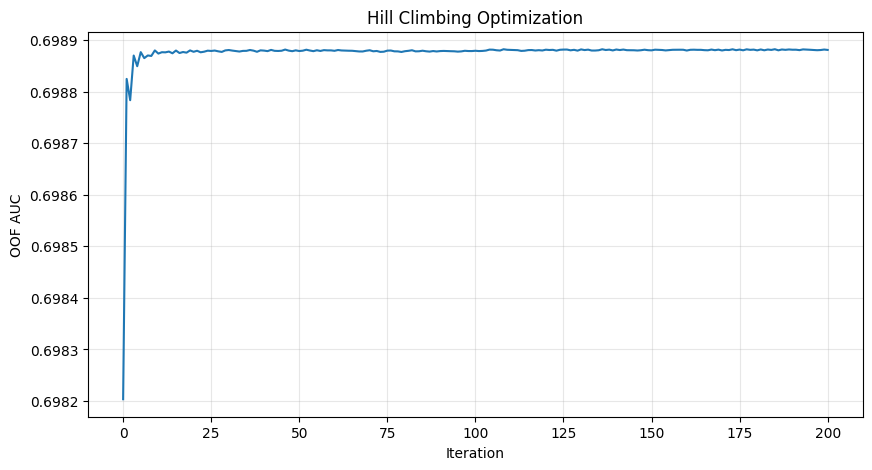

In [11]:
# Run Optimization
weights, history = hill_climbing(oof_cdf, y_true, iterations=200, verbose=True)

# Results & Submission
print("\nOptimal Blending Weights:")
for model, weight in sorted(weights.items(), key=lambda x: x[1], reverse=True):
    if weight > 0:
        print(f"{model}: {weight:.4f}")

# Plot history
plt.figure(figsize=(10, 5))
plt.plot(history)
plt.title("Hill Climbing Optimization")
plt.xlabel("Iteration")
plt.ylabel("OOF AUC")
plt.grid(True, alpha=0.3)
plt.show()

## Final Ensemble & Submission

### Generating Weighted Test Predictions

Now that we have optimized the blending weights using the OOF (validation) data, we apply these exact weights to the **Test Set**.

**Important:** We must use the **Rank-Normalized (CDF)** version of the test predictions (test\_cdf), not the raw probabilities. The Hill Climbing algorithm optimized the weights specifically for rank-transformed data. If we applied these weights to the raw probabilities, the calibration differences between models (e.g., CatBoost vs. XGBoost distributions) would break the ensemble logic.

The final prediction for each sample is calculated as:

$$
\text{Final Prediction} = \sum (\text{Model Rank} \times \text{Model Weight})
$$

This results in a robust, rank-based probability score that is ready for submission.

In [12]:
# Apply weights to Test Predictions
# Note: We apply weights to the CDF (Ranked) test predictions
final_test_preds = np.zeros(len(test_cdf))
for model, weight in weights.items():
    final_test_preds += test_cdf[model] * weight

# Save Submission
submission_df[TARGET] = final_test_preds

submission_df.to_csv('submission.csv', index=False)
print('Saved: submission.csv')

print('SUBMISSION')
print('==========')

print(submission_df.head(10))

Saved: submission.csv
SUBMISSION
       id  diagnosed_diabetes
0  700000               0.294
1  700001               0.619
2  700002               0.778
3  700003               0.179
4  700004               0.963
5  700005               0.526
6  700006               0.734
7  700007               0.971
8  700008               0.446
9  700009               0.871
